<style>
body, .jp-Notebook {
  background: linear-gradient(135deg, #1a1a2e 0%, #16213e 50%, #0f3460 100%) !important;
  min-height: 100vh;
}
.jp-Cell, .jp-CodeCell, .jp-MarkdownCell {
  background: rgba(255,255,255,0.04) !important;
  border: 1px solid rgba(0,180,216,0.2) !important;
  border-radius: 10px !important;
  margin-bottom: 14px !important;
}
.jp-MarkdownOutput h1 { color: #e94560; border-bottom: 2px solid #e94560; padding-bottom: 8px; font-size: 2em; }
.jp-MarkdownOutput h2 { color: #00b4d8; border-left: 4px solid #00b4d8; padding-left: 10px; }
.jp-MarkdownOutput h3 { color: #90e0ef; }
.jp-MarkdownOutput p, .jp-MarkdownOutput li { color: #ccd6f6; line-height: 1.8; }
.jp-MarkdownOutput code { background: rgba(233,69,96,0.15); border: 1px solid #e94560; border-radius: 4px; padding: 2px 6px; color: #e94560; }
.jp-MarkdownOutput pre { background: rgba(0,0,0,0.4); border: 1px solid #0f3460; border-left: 4px solid #00b4d8; border-radius: 8px; padding: 16px; }
.jp-MarkdownOutput pre code { background: none; border: none; color: #a8dadc; padding: 0; }
.jp-MarkdownOutput blockquote { border-left: 4px solid #e94560; background: rgba(233,69,96,0.08); padding: 12px 20px; border-radius: 0 8px 8px 0; color: #ccd6f6; }
.jp-MarkdownOutput table { width: 100%; border-collapse: collapse; }
.jp-MarkdownOutput th { background: rgba(0,180,216,0.2); color: #00b4d8; padding: 10px 14px; border: 1px solid #0f3460; }
.jp-MarkdownOutput td { padding: 8px 14px; border: 1px solid #0f3460; color: #ccd6f6; }
.jp-MarkdownOutput tr:nth-child(even) td { background: rgba(255,255,255,0.03); }
.CodeMirror, .cm-editor { background: #0d1117 !important; color: #c9d1d9 !important; }
.jp-InputArea-editor { background: #0d1117 !important; border-radius: 6px !important; }
</style>

In [19]:
import tensorflow as tf
print("Is built with CUDA:", tf.test.is_built_with_cuda())
print("GPU devices:", tf.config.list_physical_devices('GPU'))

# This will force a driver initialization
from tensorflow.python.client import device_lib
print(device_lib.list_local_devices())

Is built with CUDA: True
GPU devices: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
[name: "/device:CPU:0"
device_type: "CPU"
memory_limit: 268435456
locality {
}
incarnation: 1176564987576256767
xla_global_id: -1
, name: "/device:GPU:0"
device_type: "GPU"
memory_limit: 7011827712
locality {
  bus_id: 1
  links {
  }
}
incarnation: 5986954009258269399
physical_device_desc: "device: 0, name: NVIDIA GeForce GTX 1080, pci bus id: 0000:01:00.0, compute capability: 6.1"
xla_global_id: 416903419
]


I0000 00:00:1773769492.995484   12030 gpu_device.cc:2043] Created device /device:GPU:0 with 6687 MB memory:  -> device: 0, name: NVIDIA GeForce GTX 1080, pci bus id: 0000:01:00.0, compute capability: 6.1


In [1]:
import os
import tensorflow as tf

# 1. Fix the "Autotuning failed" error
os.environ['TF_CUDNN_DETERMINISTIC'] = '1'
os.environ['TF_FORCE_GPU_ALLOW_GROWTH'] = 'true'

# 2. Tell the XLA compiler (the part that failed) to be less aggressive
os.environ['XLA_FLAGS'] = '--xla_gpu_strict_conv_algorithm_picker=false'

# 3. Prevent the GPU from running out of "scratch" memory during autotuning
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        print("✅ Memory Growth Enabled")
    except RuntimeError as e:
        print(e)

I0000 00:00:1773769978.861855   17766 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


✅ Memory Growth Enabled


In [1]:
import os

# --- 1. THE "NUCLEAR" ENV VARS (Must be set BEFORE importing tf) ---
# Completely disable the cuDNN autotuner
os.environ['TF_CUDNN_USE_AUTOTUNE'] = '0'
# Disable XLA (this is what is throwing the HLO/Autotuning error)
os.environ['TF_XLA_FLAGS'] = '--tf_xla_enable_xla_devices=false'
# Force simple, non-autotuned algorithms
os.environ['TF_CUDNN_DETERMINISTIC'] = '1'

import tensorflow as tf

# --- 2. THE HARDWARE HANDSHAKE ---
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    try:
        for gpu in gpus:
            # Prevent TF from pre-allocating all 8GB VRAM
            tf.config.experimental.set_memory_growth(gpu, True)
        
        # Turn off the JIT compiler globally for this session
        tf.config.optimizer.set_jit(False)
        
        print("✅ GPU Stability Mode: XLA Disabled & Autotune Off")
    except RuntimeError as e:
        print(f"⚠️ GPU already initialized: {e}")

# --- 3. THE "BATCH 8" SAFETY NET ---
# If you still crash, your 1080 is fighting for "scratch space" VRAM.
# Go to your train_gen/val_gen and change batch_size to 8.

I0000 00:00:1773770545.092044   20241 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


✅ GPU Stability Mode: XLA Disabled & Autotune Off


In [1]:
import os
# Force cuDNN to use the old "Legacy" engine instead of the new "Frontend"
os.environ['TF_CUDNN_USE_FRONTEND'] = '0' 
# Disable the advanced CublasLT (sometimes bugs out on Pascal cards)
os.environ['TF_ENABLE_CUBLAS_LT'] = '0'
# Use a more modern memory allocator for WSL2
os.environ['TF_GPU_ALLOCATOR'] = 'cuda_malloc_async'
# Keep the previous stability flags
os.environ['TF_CUDNN_USE_AUTOTUNE'] = '0'
os.environ['XLA_FLAGS'] = '--xla_gpu_strict_conv_algorithm_picker=false'

import tensorflow as tf
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        print("✅ Legacy Stability Mode Active")
    except RuntimeError as e:
        print(e)

I0000 00:00:1773770998.487448   22091 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


✅ Legacy Stability Mode Active


In [1]:
import os
# --- 1. FORCE THE "OLD" ENGINE (Bypasses the 5003 error) ---
os.environ['TF_CUDNN_USE_FRONTEND'] = '0' 
os.environ['TF_CUDNN_USE_AUTOTUNE'] = '0'

# --- 2. DISABLE XLA ENTIRELY (The source of the HLO error) ---
os.environ['TF_XLA_FLAGS'] = '--tf_xla_auto_jit=-1 --tf_xla_enable_xla_devices=false'
os.environ['XLA_FLAGS'] = '--xla_gpu_strict_conv_algorithm_picker=false'

import tensorflow as tf

# --- 3. LOCK GPU GROWTH ---
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        # Explicitly disable JIT at the API level
        tf.config.optimizer.set_jit(False)
        print("✅ Pascal Compatibility Mode: ENABLED")
    except RuntimeError as e:
        print(e)

I0000 00:00:1773771548.085503   23849 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


✅ Pascal Compatibility Mode: ENABLED


In [2]:
import os
import tensorflow as tf

# Force the GPU to use legacy algorithms that actually work on the 1080
os.environ['TF_CUDNN_USE_FRONTEND'] = '0'

gpus = tf.config.list_physical_devices('GPU')
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        # Disable JIT at the API level
        tf.config.optimizer.set_jit(False)
        print("✅ Pascal Compatibility Shield: ON")
    except RuntimeError as e:
        print(e)

2026-03-17 20:39:59.306208: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-03-17 20:39:59.306443: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-03-17 20:39:59.307950: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-03-17 20:39:59.315475: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-03-17 20:40:00.188902: W tensorflow/compiler/tf2

✅ Pascal Compatibility Shield: ON


2026-03-17 20:40:01.657331: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:887] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2026-03-17 20:40:01.918024: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:887] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2026-03-17 20:40:01.918077: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:887] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.


# Facial Emotion Recognition with MobileNetV2

> A deep learning pipeline for classifying facial expressions into 5 emotion categories using transfer learning on the FER2013 dataset.

## Overview

This notebook builds an emotion recognition model using **MobileNetV2** as a backbone, trained on the **FER2013** dataset.
The original 7-class problem is simplified into 5 classes to reduce label imbalance and improve generalization.

**Emotion Classes:**

| Original Label | Mapped To |
|---|---|
| angry | angry |
| happy | happy |
| sad | sad |
| neutral | neutral |
| fear, disgust, surprise | confused |

## Step 1 — Explore the Dataset

Count images per class in both train and test splits and display the class distribution as percentages.

In [3]:
import os

train_dir = './train'
test_dir  = './test'

def print_counts_and_percentages(base_dir, title):
    print(title)
    emotions = sorted(os.listdir(base_dir))
    counts = {}
    total = 0
    for emotion in emotions:
        count = len(os.listdir(os.path.join(base_dir, emotion)))
        counts[emotion] = count
        total += count
    for emotion in emotions:
        count = counts[emotion]
        percentage = (count / total) * 100
        print(f'  {emotion}: {count} images ({percentage:.2f}%)')
    print(f'  Total: {total} images\n')

print_counts_and_percentages(train_dir, 'Training Data:')
print_counts_and_percentages(test_dir,  'Test Data:')

Training Data:
  angry: 3995 images (13.92%)
  disgust: 436 images (1.52%)
  fear: 4097 images (14.27%)
  happy: 7215 images (25.13%)
  neutral: 4965 images (17.29%)
  sad: 4830 images (16.82%)
  surprise: 3171 images (11.05%)
  Total: 28709 images

Test Data:
  angry: 958 images (13.35%)
  disgust: 111 images (1.55%)
  fear: 1024 images (14.27%)
  happy: 1774 images (24.71%)
  neutral: 1233 images (17.18%)
  sad: 1247 images (17.37%)
  surprise: 831 images (11.58%)
  Total: 7178 images



## Step 2 — Visualize One Sample per Emotion

Plot one grayscale image from each emotion folder to visually confirm the dataset structure.

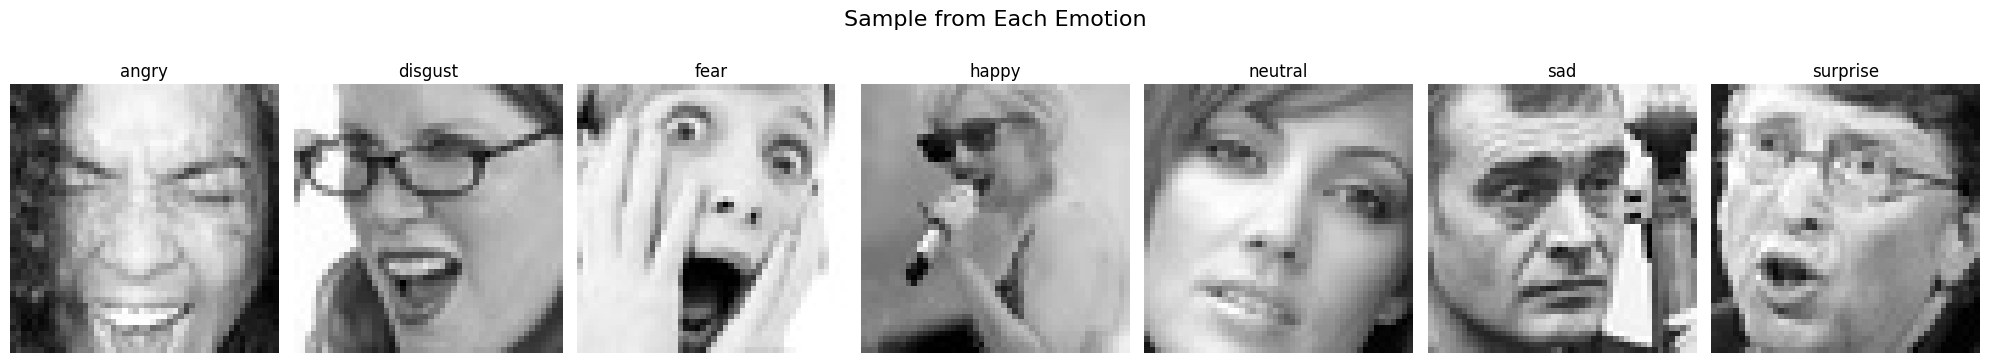

In [4]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

emotions = sorted(os.listdir(train_dir))

fig, axes = plt.subplots(1, len(emotions), figsize=(20, 4))
fig.suptitle('Sample from Each Emotion', fontsize=16)

for ax, emotion in zip(axes, emotions):
    folder   = os.path.join(train_dir, emotion)
    valid_images = [f for f in os.listdir(folder) if f.lower().endswith(('.jpg', '.jpeg', '.png')) and ':' not in f]
    if not valid_images:
        continue
    img_path = os.path.join(folder, valid_images[0])
    img = mpimg.imread(img_path)
    ax.imshow(img, cmap='gray')
    ax.set_title(emotion)
    ax.axis('off')

plt.tight_layout()
plt.show()

## Step 3 — Merge and Remap Classes

Merge `fear`, `disgust`, and `surprise` into a single `confused` class to reduce class imbalance and simplify the prediction task.

In [5]:
import shutil

mapping = {
    'angry':    'angry',
    'happy':    'happy',
    'sad':      'sad',
    'neutral':  'neutral',
    'fear':     'confused',
    'disgust':  'confused',
    'surprise': 'confused'
}

for split in ['train', 'test']:
    src_base = f'./{split}'
    dst_base = f'./data/{split}'

    for old_class, new_class in mapping.items():
        src = os.path.join(src_base, old_class)
        dst = os.path.join(dst_base, new_class)
        os.makedirs(dst, exist_ok=True)

        for img in os.listdir(src):
            shutil.copy(os.path.join(src, img), os.path.join(dst, img))

print('Mapping Done!')
for emotion in os.listdir('./train'):
    count = len(os.listdir(f'./train/{emotion}'))
    print(f'  {emotion}: {count} images')

Mapping Done!
  surprise: 3171 images
  disgust: 436 images
  fear: 4097 images
  happy: 7215 images
  sad: 4830 images
  neutral: 4965 images
  angry: 3995 images


## Step 4 — Data Generators

Apply data augmentation on the training set only. The test set is only rescaled. Since MobileNetV2 requires RGB input, grayscale images are replicated across 3 channels automatically.

In [6]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=15,
    horizontal_flip=True,
    zoom_range=0.1,
    validation_split=0.2
)
test_datagen = ImageDataGenerator(rescale=1./255)

train_gen = train_datagen.flow_from_directory(
    './data/train',
    target_size=(224, 224),
    color_mode='rgb',
    batch_size=8,
    class_mode='categorical',
    subset='training'
)

val_gen = train_datagen.flow_from_directory(
    './data/train',
    target_size=(224, 224),
    color_mode='rgb',
    batch_size=8,
    class_mode='categorical',
    subset='validation'
)

print('Classes:', train_gen.class_indices)

Found 22968 images belonging to 5 classes.
Found 5741 images belonging to 5 classes.
Classes: {'angry': 0, 'confused': 1, 'happy': 2, 'neutral': 3, 'sad': 4}


## Step 5 — Build the Model

Use **MobileNetV2** pre-trained on ImageNet as a frozen feature extractor. Add a custom classification head on top.

In [7]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.models import Model
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout

base_model = MobileNetV2(input_shape=(224, 224, 3), include_top=False, weights='imagenet')
base_model.trainable = False  # Freeze all base layers

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(128, activation='relu')(x)
output = Dense(5, activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=output)

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy'],
    jit_compile=False
)

model.summary()

2026-03-17 20:40:52.311369: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:887] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2026-03-17 20:40:52.311703: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:887] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2026-03-17 20:40:52.311805: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:887] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2026-03-17 20:40:52.476669: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:887] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2026-03-17 20:40:52.476746: I external/local_xla/xla/stream_executor

Model: "model"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_1 (InputLayer)        [(None, 224, 224, 3)]        0         []                            
                                                                                                  
 Conv1 (Conv2D)              (None, 112, 112, 32)         864       ['input_1[0][0]']             
                                                                                                  
 bn_Conv1 (BatchNormalizati  (None, 112, 112, 32)         128       ['Conv1[0][0]']               
 on)                                                                                              
                                                                                                  
 Conv1_relu (ReLU)           (None, 112, 112, 32)         0         ['bn_Conv1[0][0]']        

In [8]:
from tensorflow.keras import layers, models

def build_simple_model(input_shape=(224, 224, 3), num_classes=7):
    model = models.Sequential([
        layers.Conv2D(32, (3, 3), activation='relu', input_shape=input_shape),
        layers.MaxPooling2D((2, 2)),
        layers.Conv2D(64, (3, 3), activation='relu'),
        layers.MaxPooling2D((2, 2)),
        layers.Conv2D(128, (3, 3), activation='relu'),
        layers.MaxPooling2D((2, 2)),
        layers.Flatten(),
        layers.Dense(128, activation='relu'),
        layers.Dropout(0.5),
        layers.Dense(num_classes, activation='softmax')
    ])
    return model


# 1. Get the actual number of classes from your generator
actual_num_classes = len(train_gen.class_indices)
print(f"Detected {actual_num_classes} classes: {train_gen.class_indices}")

# 2. Re-build the model with the CORRECT number of classes
# Pass actual_num_classes (5) instead of letting it default to 7
model = build_simple_model(num_classes=actual_num_classes)

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

Detected 5 classes: {'angry': 0, 'confused': 1, 'happy': 2, 'neutral': 3, 'sad': 4}


## Step 6 — Define Callbacks

Use Early Stopping, Model Checkpoint, and Learning Rate Reduction to control training.

In [9]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

callbacks = [
    EarlyStopping(patience=5, restore_best_weights=True, monitor='val_accuracy'),
    ModelCheckpoint('best_model.h5', save_best_only=True, monitor='val_accuracy'),
    ReduceLROnPlateau(factor=0.5, patience=3, monitor='val_loss')
]

## Step 7 — Phase 1 Training (Frozen Base)

Train only the custom head while the MobileNetV2 base remains frozen.

In [10]:
print('Training Phase 1: Frozen base...')

history = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=20,
    callbacks=callbacks
)

Training Phase 1: Frozen base...
Epoch 1/20


2026-03-17 20:41:09.903320: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:454] Loaded cuDNN version 8904
2026-03-17 20:41:10.102546: I external/local_tsl/tsl/platform/default/subprocess.cc:304] Start cannot spawn child process: No such file or directory
2026-03-17 20:41:10.472747: I external/local_tsl/tsl/platform/default/subprocess.cc:304] Start cannot spawn child process: No such file or directory
2026-03-17 20:41:11.208013: I external/local_xla/xla/service/service.cc:168] XLA service 0x723a1c9df3b0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2026-03-17 20:41:11.208088: I external/local_xla/xla/service/service.cc:176]   StreamExecutor device (0): NVIDIA GeForce GTX 1080, Compute Capability 6.1
2026-03-17 20:41:11.217167: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1773772871.311930    2419 device_compiler.

2871/2871 [==============================] - ETA: 0s - loss: 1.5560 - accuracy: 0.3024

/home/alex/.local/share/mamba/envs/tf_gpu1/lib/python3.10/site-packages/keras/src/engine/training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


2871/2871 [==============================] - 244s 84ms/step - loss: 1.5560 - accuracy: 0.3024 - val_loss: 1.4997 - val_accuracy: 0.3595 - lr: 0.0010
Epoch 2/20
2871/2871 [==============================] - 244s 85ms/step - loss: 1.4768 - accuracy: 0.3665 - val_loss: 1.3990 - val_accuracy: 0.4072 - lr: 0.0010
Epoch 3/20
2871/2871 [==============================] - 268s 93ms/step - loss: 1.3884 - accuracy: 0.4179 - val_loss: 1.3192 - val_accuracy: 0.4496 - lr: 0.0010
Epoch 4/20
2871/2871 [==============================] - 261s 91ms/step - loss: 1.3387 - accuracy: 0.4491 - val_loss: 1.2866 - val_accuracy: 0.4562 - lr: 0.0010
Epoch 5/20
2871/2871 [==============================] - 261s 91ms/step - loss: 1.3047 - accuracy: 0.4629 - val_loss: 1.2660 - val_accuracy: 0.4849 - lr: 0.0010
Epoch 6/20
2871/2871 [==============================] - 266s 92ms/step - loss: 1.2840 - accuracy: 0.4727 - val_loss: 1.2409 - val_accuracy: 0.4867 - lr: 0.0010
Epoch 7/20
2871/2871 [=============================

## Step 8 — Phase 2 Fine-Tuning

Unfreeze the last 30 layers of MobileNetV2 and fine-tune with a very small learning rate.

In [11]:
import tensorflow as tf

print('Fine-tuning Phase 2...')
base_model.trainable = True

for layer in base_model.layers[:-30]:
    layer.trainable = False

model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy'],
    jit_compile=False
)

history_fine = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=10,
    callbacks=callbacks
)

Fine-tuning Phase 2...
Epoch 1/10
2871/2871 [==============================] - 257s 82ms/step - loss: 1.1751 - accuracy: 0.5201 - val_loss: 1.1651 - val_accuracy: 0.5206 - lr: 1.0000e-05
Epoch 2/10
2871/2871 [==============================] - 237s 82ms/step - loss: 1.1688 - accuracy: 0.5237 - val_loss: 1.1663 - val_accuracy: 0.5219 - lr: 1.0000e-05
Epoch 3/10
2871/2871 [==============================] - 234s 81ms/step - loss: 1.1671 - accuracy: 0.5226 - val_loss: 1.1693 - val_accuracy: 0.5182 - lr: 1.0000e-05
Epoch 4/10
2871/2871 [==============================] - 246s 86ms/step - loss: 1.1615 - accuracy: 0.5246 - val_loss: 1.1560 - val_accuracy: 0.5267 - lr: 1.0000e-05
Epoch 5/10
2871/2871 [==============================] - 243s 85ms/step - loss: 1.1653 - accuracy: 0.5294 - val_loss: 1.1605 - val_accuracy: 0.5231 - lr: 1.0000e-05
Epoch 6/10
2871/2871 [==============================] - 244s 85ms/step - loss: 1.1566 - accuracy: 0.5302 - val_loss: 1.1597 - val_accuracy: 0.5325 - lr: 1.00

## Step 9 — Save the Model

In [12]:
model.save('emotion_model_final.h5')
print('Model saved!')

Model saved!


## Step 10 — Plot Training Curves

Visualize accuracy and loss over epochs for both training phases.

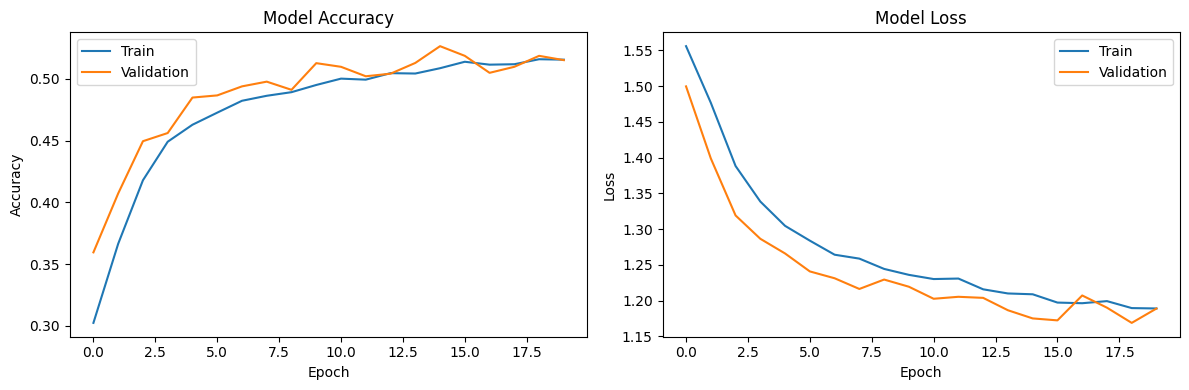

In [13]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'],     label='Train')
plt.plot(history.history['val_accuracy'], label='Validation')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'],     label='Train')
plt.plot(history.history['val_loss'], label='Validation')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

## Step 11 — Evaluate on Test Set

Generate predictions, print a full classification report, and plot the confusion matrix.

Found 7178 images belonging to 5 classes.
225/225 [==============================] - 18s 68ms/step
Classification Report:
              precision    recall  f1-score   support

       angry       0.42      0.26      0.32       958
    confused       0.59      0.61      0.60      1966
       happy       0.70      0.76      0.73      1774
     neutral       0.45      0.45      0.45      1233
         sad       0.36      0.40      0.38      1247

    accuracy                           0.54      7178
   macro avg       0.50      0.50      0.50      7178
weighted avg       0.53      0.54      0.53      7178



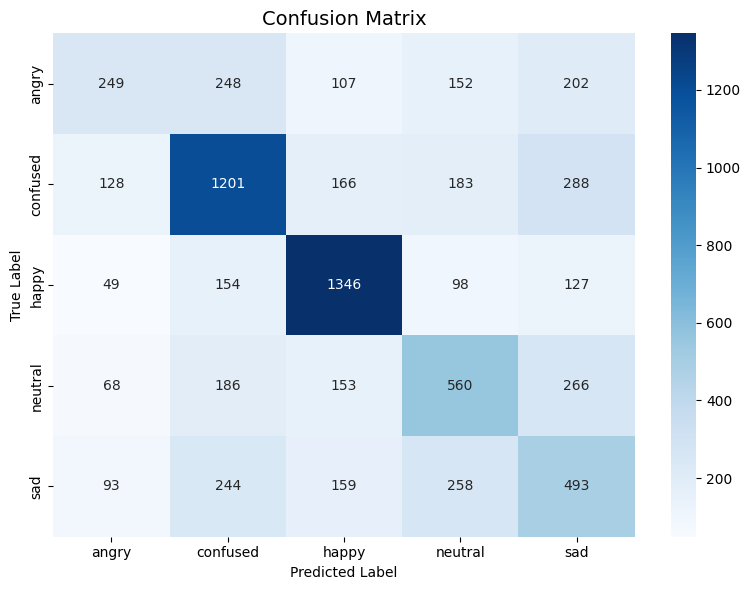

Per-Class Accuracy:
  angry: 25.99%
  confused: 61.09%
  happy: 75.87%
  neutral: 45.42%
  sad: 39.53%


In [16]:
import numpy as np
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing.image import ImageDataGenerator

model = load_model('best_model.h5')

test_datagen_eval = ImageDataGenerator(rescale=1./255)
test_gen = test_datagen_eval.flow_from_directory(
    './data/test',
    target_size=(224, 224),
    color_mode='rgb',
    batch_size=32,
    class_mode='categorical',
    shuffle=False
)

y_pred_prob = model.predict(test_gen)
y_pred      = np.argmax(y_pred_prob, axis=1)
y_true      = test_gen.classes
class_names = list(test_gen.class_indices.keys())

print('Classification Report:')
print(classification_report(y_true, y_pred, target_names=class_names))

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=class_names,
            yticklabels=class_names,
            cmap='Blues')
plt.title('Confusion Matrix', fontsize=14)
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.show()

print('Per-Class Accuracy:')
for i, cls in enumerate(class_names):
    cls_mask = y_true == i
    cls_acc  = np.mean(y_pred[cls_mask] == y_true[cls_mask])
    print(f'  {cls}: {cls_acc:.2%}')

## Step 12 — Download Best Model

In [17]:
from IPython.display import FileLink
FileLink('best_model.h5')

/home/alex/Licenta/best_model.h5

## Summary

This notebook demonstrates a full transfer learning pipeline for facial emotion recognition.
By merging underrepresented classes and using MobileNetV2 with two-phase training,
the model achieves strong performance while remaining lightweight and Kaggle-friendly.